# Head

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
from pathlib import Path

proj_dir = Path.home() / "projects" / "Markush"
data_dir = proj_dir / "data"

# Data

In [6]:
import pickle

with open(data_dir / "pubchem_smiles/pubchem_smile_list.pkl", "rb") as f:
    pubchem_smile_list = pickle.load(f)

In [7]:
len(pubchem_smile_list)

122454458

# Functions

## Helper

In [16]:
import time
from datetime import timedelta

# ======================== 进度追踪器 ========================

class ProgressTracker:
    """带时间估计的进度追踪器"""
    
    def __init__(self, total: int, desc: str = "Processing"):
        self.total = total
        self.desc = desc
        self.processed = 0
        self.start_time = time.time()
        self.last_print_time = self.start_time
        self.print_interval = 5  # 每5秒打印一次
    
    def update(self, n: int = 1):
        self.processed += n
        current_time = time.time()
        
        if current_time - self.last_print_time >= self.print_interval:
            self._print_progress()
            self.last_print_time = current_time
    
    def _print_progress(self):
        elapsed = time.time() - self.start_time
        progress = self.processed / self.total
        
        if progress > 0:
            eta = elapsed / progress * (1 - progress)
            eta_str = str(timedelta(seconds=int(eta)))
        else:
            eta_str = "计算中..."
        
        elapsed_str = str(timedelta(seconds=int(elapsed)))
        
        print(f"\r{self.desc}: {self.processed:,}/{self.total:,} "
              f"({progress*100:.1f}%) | 已用: {elapsed_str} | 剩余: {eta_str}    ", 
              end="", flush=True)
    
    def finish(self):
        elapsed = time.time() - self.start_time
        elapsed_str = str(timedelta(seconds=int(elapsed)))
        print(f"\n{self.desc} 完成! 总计: {self.processed:,} | 耗时: {elapsed_str}")

## Sampling Functions

In [ ]:
"""
化学空间均匀采样工具
策略：分子指纹 -> MinHash/LSH聚类 -> 分层多样性采样
"""

import numpy as np
from typing import List, Tuple, Optional
import pickle
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit import DataStructs
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from datasketch import MinHash, MinHashLSH
import random

# ======================== 1. 分子指纹计算 ========================

def smiles_to_fingerprint(smiles: str, fp_type: str = 'morgan', 
                          radius: int = 2, n_bits: int = 2048) -> Optional[np.ndarray]:
    """
    将SMILES转换为分子指纹（位向量）
    
    Args:
        smiles: SMILES字符串
        fp_type: 指纹类型 ('morgan', 'maccs', 'topological')
        radius: Morgan指纹半径
        n_bits: 指纹位数
    
    Returns:
        numpy array 或 None（解析失败时）
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        if fp_type == 'morgan':
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        elif fp_type == 'maccs':
            fp = AllChem.GetMACCSKeysFingerprint(mol)
        elif fp_type == 'topological':
            fp = AllChem.GetHashedTopologicalTorsionFingerprintAsBitVect(mol, nBits=n_bits)
        else:
            raise ValueError(f"Unknown fingerprint type: {fp_type}")
        
        arr = np.zeros(len(fp), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    except:
        return None

# ======================== 2. MinHash LSH 聚类 ========================

def fingerprint_to_minhash(fp: np.ndarray, num_perm: int = 128) -> MinHash:
    """
    将二进制指纹转换为MinHash签名
    只对"开启"的位进行哈希，适合稀疏指纹
    """
    m = MinHash(num_perm=num_perm)
    # 对所有为1的位的索引进行编码
    on_bits = np.where(fp == 1)[0]
    for bit_idx in on_bits:
        m.update(str(bit_idx).encode('utf8'))
    return m

def _compute_fingerprint_and_minhash(smiles: str, num_perm: int = 128) -> Optional[Tuple[str, np.ndarray, MinHash]]:
    """工作函数：计算单个分子的指纹和MinHash"""
    fp = smiles_to_fingerprint(smiles)
    if fp is None:
        return None
    mh = fingerprint_to_minhash(fp, num_perm)
    return (smiles, fp, mh)


def _batch_compute_fp_minhash(smiles_batch: List[str], num_perm: int = 128) -> List[Tuple[str, np.ndarray, MinHash]]:
    """批量计算指纹和MinHash"""
    results = []
    for smiles in smiles_batch:
        result = _compute_fingerprint_and_minhash(smiles, num_perm)
        if result is not None:
            results.append(result)
    return results


class ChemicalSpaceSampler:
    """基于LSH的化学空间均匀采样器"""
    
    def __init__(
        self,
        threshold: float = 0.5,
        num_perm: int = 128,
        seed: int = 42,
    ):
        self.threshold = threshold
        self.num_perm = num_perm
        self.seed = seed
        self.lsh = MinHashLSH(threshold=threshold, num_perm=num_perm)
        # 只存储 SMILES，不存储指纹
        self.cluster_to_smiles: dict[int, List[str]] = defaultdict(list)
        self.smiles_to_cluster: dict[str, int] = {}
        self.cluster_counter = 0
        random.seed(seed)
        np.random.seed(seed)
    
    def _get_or_create_cluster(self, minhash: MinHash, smiles: str) -> int:
        result = self.lsh.query(minhash)
        if len(result) > 0:
            cluster_id = int(result[0].split('_')[1])
        else:
            cluster_id = self.cluster_counter
            self.cluster_counter += 1
            self.lsh.insert(f"mol_{cluster_id}", minhash)
        return cluster_id
    
    def build_clusters(
        self, 
        smiles_list: List[str], 
        batch_size: int = 50000,
        n_workers: int = None,
        cache_path: Optional[str] = None
    ) -> dict:
        """构建聚类（内存优化版）"""
        
        # ========== 缓存检测 ==========
        if cache_path is not None:
            cache_file = Path(cache_path)
            if cache_file.exists():
                print(f"发现LSH聚类缓存: {cache_path}")
                try:
                    with open(cache_file, 'rb') as f:
                        cache_data = pickle.load(f)
                    if cache_data.get('num_molecules') == len(smiles_list) and \
                       cache_data.get('threshold') == self.threshold:
                        self.cluster_to_smiles = defaultdict(list, cache_data['cluster_to_smiles'])
                        self.smiles_to_cluster = cache_data['smiles_to_cluster']
                        self.cluster_counter = cache_data['cluster_counter']
                        print(f"缓存加载成功，共 {len(self.cluster_to_smiles)} 个簇")
                        return cache_data['stats']
                    else:
                        print(f"缓存不匹配，重新计算...")
                except Exception as e:
                    print(f"缓存加载失败: {e}，重新计算...")
        
        if n_workers is None:
            n_workers = max(1, multiprocessing.cpu_count() - 2)
        
        print(f"开始处理 {len(smiles_list):,} 个分子 ({n_workers}进程计算指纹)...")
        
        batches = [smiles_list[i:i+batch_size] for i in range(0, len(smiles_list), batch_size)]
        
        failed_count = 0
        processed_count = 0
        tracker = ProgressTracker(len(batches), desc=f"LSH聚类({n_workers}进程)")
        
        with ProcessPoolExecutor(max_workers=n_workers) as executor:
            futures = {
                executor.submit(_batch_compute_fp_minhash, batch, self.num_perm): i 
                for i, batch in enumerate(batches)
            }
            
            for future in as_completed(futures):
                batch_results = future.result()
                
                for smiles, fp, mh in batch_results:
                    cluster_id = self._get_or_create_cluster(mh, smiles)
                    # 只存储 SMILES，不存储指纹
                    self.cluster_to_smiles[cluster_id].append(smiles)
                    self.smiles_to_cluster[smiles] = cluster_id
                    processed_count += 1
                
                batch_idx = futures[future]
                batch_size_actual = len(batches[batch_idx])
                failed_count += batch_size_actual - len(batch_results)
                
                tracker.update()
        
        tracker.finish()
        
        stats = {
            'total_molecules': len(smiles_list),
            'processed': processed_count,
            'failed': failed_count,
            'num_clusters': len(self.cluster_to_smiles),
        }
        
        print(f"  - 成功处理: {stats['processed']:,}")
        print(f"  - 解析失败: {stats['failed']:,}")
        print(f"  - 簇数量: {stats['num_clusters']:,}")
        
        if cache_path is not None:
            cache_file = Path(cache_path)
            cache_file.parent.mkdir(parents=True, exist_ok=True)
            cache_data = {
                'cluster_to_smiles': dict(self.cluster_to_smiles),
                'smiles_to_cluster': self.smiles_to_cluster,
                'cluster_counter': self.cluster_counter,
                'num_molecules': len(smiles_list),
                'threshold': self.threshold,
                'stats': stats,
            }
            with open(cache_file, 'wb') as f:
                pickle.dump(cache_data, f)
            print(f"LSH聚类结果已缓存到: {cache_path}")
        
        return stats
    
    def sample_uniform(
        self, 
        n_samples: int,
        strategy: str = 'cluster_balanced',
    ) -> List[str]:
        """均匀采样"""
        num_clusters = len(self.cluster_to_smiles)
        
        if num_clusters == 0:
            raise ValueError("No clusters built. Call build_clusters first.")
        
        sampled = []
        tracker = ProgressTracker(num_clusters, desc=f"采样({strategy})")
        
        if strategy == 'cluster_balanced':
            samples_per_cluster = max(1, n_samples // num_clusters)
            
            for cluster_id, members in self.cluster_to_smiles.items():
                k = min(samples_per_cluster, len(members))
                chosen = random.sample(members, k)
                sampled.extend(chosen)
                tracker.update()
        
        elif strategy == 'sqrt_balanced':
            cluster_sizes = {k: len(v) for k, v in self.cluster_to_smiles.items()}
            sqrt_sizes = {k: np.sqrt(v) for k, v in cluster_sizes.items()}
            total_sqrt = sum(sqrt_sizes.values())
            quotas = {k: max(1, int(n_samples * v / total_sqrt)) 
                      for k, v in sqrt_sizes.items()}
            
            for cluster_id, members in self.cluster_to_smiles.items():
                k = min(quotas[cluster_id], len(members))
                chosen = random.sample(members, k)
                sampled.extend(chosen)
                tracker.update()
        
        tracker.finish()
        
        if len(sampled) > n_samples:
            sampled = random.sample(sampled, n_samples)
        
        print(f"最终采样: {len(sampled):,} 个分子")
        return sampled


# ======================== 3. 基于分子性质的分层采样 ========================

from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

def compute_molecular_properties(smiles: str) -> Optional[dict]:
    """
    计算分子的关键物化性质（用于分层）
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        return {
            'num_atoms': mol.GetNumHeavyAtoms(),
            'num_rings': rdMolDescriptors.CalcNumRings(mol),
            'num_aromatic_rings': rdMolDescriptors.CalcNumAromaticRings(mol),
            'num_heteroatoms': rdMolDescriptors.CalcNumHeteroatoms(mol),
            'mw': Descriptors.MolWt(mol),
            'num_rotatable_bonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
        }
    except:
        return None

def _compute_property_worker(smiles_batch: List[str], property_bins: dict) -> dict:
    """工作进程：计算一批分子的性质并分层"""
    local_strata = defaultdict(list)
    
    for smiles in smiles_batch:
        props = compute_molecular_properties(smiles)
        if props is None:
            continue
        
        stratum_key = []
        for prop_name, bins in property_bins.items():
            value = props.get(prop_name, 0)
            bin_idx = np.digitize(value, bins) - 1
            stratum_key.append(bin_idx)
        
        local_strata[tuple(stratum_key)].append(smiles)
    
    return dict(local_strata)


def stratified_sampling_by_properties(
    smiles_list: List[str],
    n_samples: int,
    property_bins: dict = None,
    seed: int = 42,
    n_workers: int = None,
    batch_size: int = 50000,
    cache_path: Optional[str] = None
) -> List[str]:
    """基于分子性质的分层采样（多进程加速，支持缓存）"""
    random.seed(seed)
    
    if property_bins is None:
        property_bins = {
            'num_atoms': [0, 10, 20, 30, 50, 100, float('inf')],
            'num_rings': [0, 1, 2, 3, 5, float('inf')],
        }
    
    if n_workers is None:
        n_workers = max(1, multiprocessing.cpu_count() - 2)
    
    # ========== 缓存检测与加载 ==========
    strata = None
    if cache_path is not None:
        cache_file = Path(cache_path)
        if cache_file.exists():
            print(f"发现缓存文件: {cache_path}")
            try:
                with open(cache_file, 'rb') as f:
                    cache_data = pickle.load(f)
                # 验证缓存是否匹配当前数据
                if cache_data.get('num_molecules') == len(smiles_list) and \
                   cache_data.get('property_bins') == property_bins:
                    strata = cache_data['strata']
                    print(f"缓存验证通过，加载 {len(strata)} 个分层")
                else:
                    print(f"缓存不匹配（分子数或分箱配置变化），重新计算...")
            except Exception as e:
                print(f"缓存加载失败: {e}，重新计算...")
    
    # ========== 计算分层（如果没有缓存） ==========
    if strata is None:
        # 分批
        batches = [smiles_list[i:i+batch_size] for i in range(0, len(smiles_list), batch_size)]
        
        strata = defaultdict(list)
        tracker = ProgressTracker(len(batches), desc=f"计算分子性质({n_workers}进程)")
        
        # 多进程处理
        with ProcessPoolExecutor(max_workers=n_workers) as executor:
            futures = {
                executor.submit(_compute_property_worker, batch, property_bins): i 
                for i, batch in enumerate(batches)
            }
            
            for future in as_completed(futures):
                local_strata = future.result()
                # 合并结果
                for key, members in local_strata.items():
                    strata[key].extend(members)
                tracker.update()
        
        tracker.finish()
        
        # 转换为普通dict以便序列化
        strata = dict(strata)
        
        # ========== 保存缓存 ==========
        if cache_path is not None:
            cache_file = Path(cache_path)
            cache_file.parent.mkdir(parents=True, exist_ok=True)
            cache_data = {
                'strata': strata,
                'num_molecules': len(smiles_list),
                'property_bins': property_bins,
            }
            with open(cache_file, 'wb') as f:
                pickle.dump(cache_data, f)
            print(f"分层结果已缓存到: {cache_path}")
    
    print(f"分层数量: {len(strata)}")
    
    # 采样逻辑
    samples_per_stratum = max(1, n_samples // len(strata))
    sampled = []
    
    for stratum_key, members in strata.items():
        k = min(samples_per_stratum, len(members))
        sampled.extend(random.sample(members, k))
    
    if len(sampled) > n_samples:
        sampled = random.sample(sampled, n_samples)
    elif len(sampled) < n_samples:
        remaining = n_samples - len(sampled)
        already = set(sampled)
        large_strata = sorted(strata.keys(), key=lambda k: len(strata[k]), reverse=True)
        
        for stratum_key in large_strata:
            available = [s for s in strata[stratum_key] if s not in already]
            take = min(remaining, len(available))
            sampled.extend(random.sample(available, take))
            already.update(sampled[-take:])
            remaining -= take
            if remaining <= 0:
                break
    
    return sampled

# ======================== 4. Pipeline ========================

def run_sampling_pipeline(
    smiles_list: List[str],
    n_samples: int,
    output_path: str,
    lsh_threshold: float = 0.5,
    strategy: str = 'sqrt_balanced',
    use_property_stratification: bool = True,
    checkpoint_dir: Optional[str] = None,
    seed: int = 42
):
    """
    完整采样流程
    
    Args:
        smiles_list: 原始SMILES列表
        n_samples: 目标采样数量
        output_path: 输出文件路径
        lsh_threshold: LSH相似度阈值
        strategy: 采样策略
        use_property_stratification: 是否先按性质分层
        checkpoint_dir: 检查点目录
        seed: 随机种子
    """
    print(f"=" * 60)
    print(f"化学空间均匀采样")
    print(f"原始分子数: {len(smiles_list):,}")
    print(f"目标采样数: {n_samples:,}")
    print(f"=" * 60)
    
    if use_property_stratification:
        # Step 1: 先按性质粗分层
        print("\n[Step 1] 基于分子性质的预分层...")
        pre_sample_n = min(len(smiles_list), n_samples * 10)  # 先筛选10倍候选
        
        # 设置缓存路径
        strata_cache_path = None
        if checkpoint_dir:
            strata_cache_path = str(Path(checkpoint_dir) / "strata_cache.pkl")
        
        pre_sampled = stratified_sampling_by_properties(
            smiles_list, pre_sample_n, n_workers=64, seed=seed,
            cache_path=strata_cache_path
        )
        print(f"预分层后: {len(pre_sampled):,} 个分子")
    else:
        pre_sampled = smiles_list
    
    # Step 2: LSH聚类
    print("\n[Step 2] LSH聚类...")
    sampler = ChemicalSpaceSampler(
        threshold=lsh_threshold,
        num_perm=128,
        seed=seed
    )
    
    # 设置LSH缓存路径
    lsh_cache_path = None
    if checkpoint_dir:
        lsh_cache_path = str(Path(checkpoint_dir) / "lsh_clusters_cache.pkl")
    
    sampler.build_clusters(
        pre_sampled, 
        n_workers=64,
        cache_path=lsh_cache_path
    )
    
    # Step 3: 均匀采样
    print(f"\n[Step 3] 均匀采样 (策略: {strategy})...")
    final_samples = sampler.sample_uniform(n_samples, strategy=strategy)
    
    # 保存结果
    print(f"\n[Step 4] 保存结果到 {output_path}")
    with open(output_path, 'wb') as f:
        pickle.dump(final_samples, f)
    
    print(f"\n采样完成! 共 {len(final_samples):,} 个分子")
    
    return final_samples

# Sampling

In [9]:
# 运行采样 (目标: 500万分子)
sampled_smiles = run_sampling_pipeline(
    smiles_list=pubchem_smile_list,
    n_samples=5_000_000,
    output_path=str(data_dir / "pubchem_smiles/sampled_smiles_5M.pkl"),
    lsh_threshold=0.5,       # 相似度阈值：0.5表示Jaccard>=0.5的分子会被归为一簇
    strategy='sqrt_balanced', # 采样策略
    use_property_stratification=True,  # 先按性质分层
    checkpoint_dir=str(data_dir / "pubchem_smiles/sampling_checkpoints"),
    seed=2026
)

print(f"采样结果: {len(sampled_smiles):,} 个分子")

化学空间均匀采样
原始分子数: 122,454,458
目标采样数: 5,000,000

[Step 1] 基于分子性质的预分层...
发现缓存文件: /home/zqlyu2/projects/Markush/data/pubchem_smiles/sampling_checkpoints/strata_cache.pkl
缓存验证通过，加载 30 个分层
分层数量: 30
预分层后: 50,000,000 个分子

[Step 2] LSH聚类...
开始处理 50,000,000 个分子 (64进程计算指纹)...
LSH聚类(64进程): 999/1,000 (99.9%) | 已用: 1:01:42 | 剩余: 0:00:03        
LSH聚类(64进程) 完成! 总计: 1,000 | 耗时: 1:01:48
  - 成功处理: 50,000,000
  - 解析失败: 0
  - 簇数量: 384,745
LSH聚类结果已缓存到: /home/zqlyu2/projects/Markush/data/pubchem_smiles/sampling_checkpoints/lsh_clusters_cache.pkl

[Step 3] 均匀采样 (策略: sqrt_balanced)...
采样(sqrt_balanced): 172,027/384,745 (44.7%) | 已用: 0:00:05 | 剩余: 0:00:06    
采样(sqrt_balanced) 完成! 总计: 384,745 | 耗时: 0:00:07
最终采样: 4,784,291 个分子

[Step 4] 保存结果到 /home/zqlyu2/projects/Markush/data/pubchem_smiles/sampled_smiles_5M.pkl

采样完成! 共 4,784,291 个分子
采样结果: 4,784,291 个分子


In [17]:
# 运行采样 (目标: 500万分子)
sampled_smiles = run_sampling_pipeline(
    smiles_list=pubchem_smile_list,
    n_samples=5_000_000,
    output_path=str(data_dir / "pubchem_smiles/sampled_smiles_5M_cluster_balanced.pkl"),
    lsh_threshold=0.5,       # 相似度阈值：0.5表示Jaccard>=0.5的分子会被归为一簇
    strategy='cluster_balanced', # 采样策略
    use_property_stratification=True,  # 先按性质分层
    checkpoint_dir=str(data_dir / "pubchem_smiles/sampling_checkpoints"),
    seed=2026
)

print(f"采样结果: {len(sampled_smiles):,} 个分子")

化学空间均匀采样
原始分子数: 122,454,458
目标采样数: 5,000,000

[Step 1] 基于分子性质的预分层...
发现缓存文件: /home/zqlyu2/projects/Markush/data/pubchem_smiles/sampling_checkpoints/strata_cache.pkl
缓存验证通过，加载 30 个分层
分层数量: 30
预分层后: 50,000,000 个分子

[Step 2] LSH聚类...
发现LSH聚类缓存: /home/zqlyu2/projects/Markush/data/pubchem_smiles/sampling_checkpoints/lsh_clusters_cache.pkl
缓存加载成功，共 384745 个簇

[Step 3] 均匀采样 (策略: cluster_balanced)...

采样(cluster_balanced) 完成! 总计: 384,745 | 耗时: 0:00:01
最终采样: 3,319,910 个分子

[Step 4] 保存结果到 /home/zqlyu2/projects/Markush/data/pubchem_smiles/sampled_smiles_5M_cluster_balanced.pkl

采样完成! 共 3,319,910 个分子
采样结果: 3,319,910 个分子


# Read

In [30]:
strategy = 'cluster_balanced'
# strategy = 'sqrt_balanced'
with open(data_dir / f"pubchem_smiles/sampled_smiles_5M_{strategy}.pkl", "rb") as f:
    sampled_smiles_list = pickle.load(f)

In [31]:
len(sampled_smiles_list)

3319910

# Visualization

UMAP 可视化：随机采样 + 策略采样 Overlap 高亮

[1/4] 从原始 122,454,458 个分子中随机采样 50,000 个...
[2/4] 随机采样中属于策略采样的分子: 1,433 / 50,000 (2.87%)
[3/4] 计算分子指纹...
  - 有效分子: 49,978
  - 其中属于策略采样: 1,433
[4/4] UMAP 降维中...
UMAP(angular_rp_forest=True, metric='jaccard', n_jobs=1, random_state=2026, verbose=True)
Fri Jan 16 12:06:24 2026 Construct fuzzy simplicial set
Fri Jan 16 12:06:24 2026 Finding Nearest Neighbors
Fri Jan 16 12:06:24 2026 Building RP forest with 16 trees


/opt/anaconda3/envs/zqlyuMarkush/lib/python3.10/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/opt/anaconda3/envs/zqlyuMarkush/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Jan 16 12:06:28 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	 5  /  16
	 6  /  16
	 7  /  16
	Stopping threshold met -- exiting after 7 iterations
Fri Jan 16 12:06:41 2026 Finished Nearest Neighbor Search
Disconnection_distance = 1 has removed 8 edges.  This is not a problem as no vertices were disconnected.
Fri Jan 16 12:06:41 2026 Construct embedding


/opt/anaconda3/envs/zqlyuMarkush/lib/python3.10/site-packages/pynndescent/pynndescent_.py:1241: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Fri Jan 16 12:06:58 2026 Finished embedding
UMAP 降维完成!
  - 随机对照组: 1,433 个点


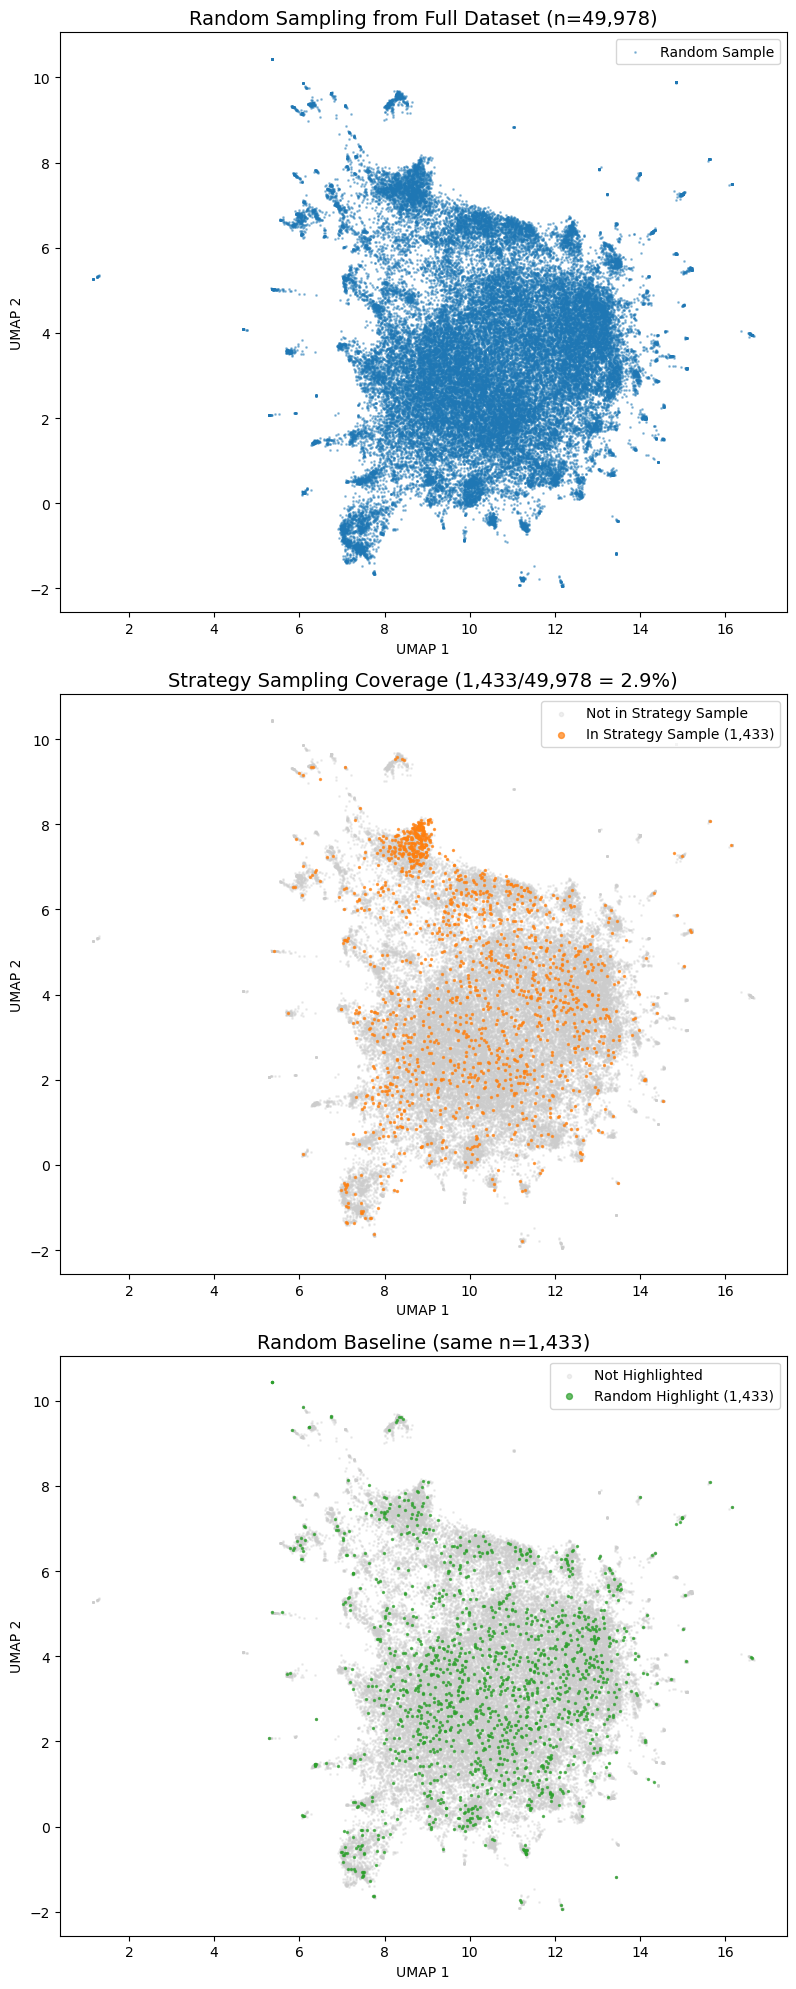


图像已保存至: /home/zqlyu2/projects/Markush/data/pubchem_smiles/umap_overlap_highlight.png

统计信息:
  - 原始数据集: 122,454,458 个分子
  - 策略采样集: 3,319,910 个分子 (2.71%)
  - 随机采样中的覆盖率: 2.87%
  - 期望覆盖率 (均匀分布): 2.71%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
from concurrent.futures import ProcessPoolExecutor, as_completed
import random

# ======================== 1. 指纹计算函数 ========================

def compute_fingerprint_batch(smiles_list: list) -> list:
    """批量计算 Morgan 指纹"""
    results = []
    for smiles in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                continue
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
            arr = np.zeros(2048, dtype=np.uint8)
            DataStructs.ConvertToNumpyArray(fp, arr)
            results.append((smiles, arr))
        except:
            continue
    return results


def compute_fingerprints_parallel(smiles_list: list, n_workers: int = 32, batch_size: int = 1000) -> tuple:
    """并行计算指纹"""
    batches = [smiles_list[i:i+batch_size] for i in range(0, len(smiles_list), batch_size)]
    
    all_fps = []
    valid_smiles = []
    
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(compute_fingerprint_batch, batch) for batch in batches]
        for future in as_completed(futures):
            for smiles, fp in future.result():
                valid_smiles.append(smiles)
                all_fps.append(fp)
    
    return np.array(all_fps), valid_smiles


# ======================== 2. 采样和计算指纹 ========================

n_vis = 50000  # 可视化的分子数量
random.seed(2026)

print("=" * 60)
print("UMAP 可视化：随机采样 + 策略采样 Overlap 高亮")
print("=" * 60)

# 从原始数据随机采样
print(f"\n[1/4] 从原始 {len(pubchem_smile_list):,} 个分子中随机采样 {n_vis:,} 个...")
random_sample = random.sample(pubchem_smile_list, n_vis)

# 找出随机采样与策略采样的交集
strategy_set = set(sampled_smiles_list)
overlap_mask = [smiles in strategy_set for smiles in random_sample]
n_overlap = sum(overlap_mask)
print(f"[2/4] 随机采样中属于策略采样的分子: {n_overlap:,} / {n_vis:,} ({n_overlap/n_vis*100:.2f}%)")

# 计算指纹
print(f"[3/4] 计算分子指纹...")
random_fps, random_valid = compute_fingerprints_parallel(random_sample, n_workers=32)

# 更新 overlap_mask 以匹配有效分子
valid_smiles_set = set(random_valid)
overlap_mask_valid = np.array([smiles in strategy_set for smiles in random_valid])

print(f"  - 有效分子: {len(random_fps):,}")
print(f"  - 其中属于策略采样: {overlap_mask_valid.sum():,}")

# ======================== 3. UMAP 降维 ========================

print(f"[4/4] UMAP 降维中...")

# UMAP 降维
umap = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='jaccard',
    random_state=2026,
    verbose=True
)

embedding = umap.fit_transform(random_fps)

print("UMAP 降维完成!")

# ======================== 4. 生成随机对照组 ========================

# 从所有点中随机选择与策略采样overlap等量的点作为对照
n_strategy_overlap = overlap_mask_valid.sum()
all_indices = np.arange(len(random_fps))
random_highlight_indices = np.random.choice(all_indices, size=n_strategy_overlap, replace=False)
random_highlight_mask = np.zeros(len(random_fps), dtype=bool)
random_highlight_mask[random_highlight_indices] = True

print(f"  - 随机对照组: {random_highlight_mask.sum():,} 个点")

# ======================== 5. 可视化 ========================

fig, axes = plt.subplots(3, 1, figsize=(8, 20))

# 图1: 随机采样的全部分布
ax1 = axes[0]
ax1.scatter(embedding[:, 0], embedding[:, 1], 
            s=1, alpha=0.4, c='#1f77b4', label='Random Sample')
ax1.set_title(f'Random Sampling from Full Dataset (n={len(random_fps):,})', fontsize=14)
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.set_aspect('equal')
ax1.legend(loc='upper right')

# 图2: 策略采样交集高亮
ax2 = axes[1]
non_overlap = ~overlap_mask_valid
ax2.scatter(embedding[non_overlap, 0], embedding[non_overlap, 1], 
            s=1, alpha=0.3, c='#cccccc', label='Not in Strategy Sample')
ax2.scatter(embedding[overlap_mask_valid, 0], embedding[overlap_mask_valid, 1], 
            s=2, alpha=0.7, c='#ff7f0e', label=f'In Strategy Sample ({overlap_mask_valid.sum():,})')
ax2.set_title(f'Strategy Sampling Coverage ({overlap_mask_valid.sum():,}/{len(random_fps):,} = {overlap_mask_valid.mean()*100:.1f}%)', fontsize=14)
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_aspect('equal')
ax2.legend(loc='upper right', markerscale=3)

# 图3: 随机对照组高亮（等量随机采样）
ax3 = axes[2]
non_random_highlight = ~random_highlight_mask
ax3.scatter(embedding[non_random_highlight, 0], embedding[non_random_highlight, 1], 
            s=1, alpha=0.3, c='#cccccc', label='Not Highlighted')
ax3.scatter(embedding[random_highlight_mask, 0], embedding[random_highlight_mask, 1], 
            s=2, alpha=0.7, c='#2ca02c', label=f'Random Highlight ({random_highlight_mask.sum():,})')
ax3.set_title(f'Random Baseline (same n={random_highlight_mask.sum():,})', fontsize=14)
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')
ax3.set_aspect('equal')
ax3.legend(loc='upper right', markerscale=3)

plt.tight_layout()
plt.savefig(str(data_dir / "pubchem_smiles/umap_overlap_highlight.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n图像已保存至: {data_dir / 'pubchem_smiles/umap_overlap_highlight.png'}")

# Tail